# Limpieza de Datos y EDA - Egresos Hospitalarios 2024

Dataset del MINSAL con los egresos hospitalarios de Chile 2024.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df_raw = pd.read_csv('EGRESOS_2024.csv', sep=';', encoding='latin1', low_memory=False)
print('filas:', df_raw.shape[0], '  columnas:', df_raw.shape[1])


filas: 1667349   columnas: 15


## 1. Analisis descriptivo

Primero veo cuantas filas y columnas tiene, los tipos de datos y como se ve la variable principal DIAS_ESTADA.


In [31]:
print('Filas:', df_raw.shape[0], '  Columnas:', df_raw.shape[1])
print()
print(df_raw.dtypes)


Filas: 1667349   Columnas: 15

PERTENENCIA_ESTABLECIMIENTO_SALUD    object
SEXO                                 object
GRUPO_EDAD                           object
GLOSA_PAIS_ORIGEN                    object
COMUNA_RESIDENCIA                    object
GLOSA_COMUNA_RESIDENCIA              object
REGION_RESIDENCIA                    object
GLOSA_REGION_RESIDENCIA              object
PREVISION                            object
GLOSA_PREVISION                      object
ANO_EGRESO                            int64
DIAG1                                object
DIAG2                                object
DIAS_ESTADA                           int64
CONDICION_EGRESO                      int64
dtype: object


In [32]:
df_raw.head(5)

,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAG2,DIAS_ESTADA,CONDICION_EGRESO
0,Pertenecientes al Sistema Nacional de Servicio...,2,20 A 24 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N908,NaN,2,1
1,Pertenecientes al Sistema Nacional de Servicio...,2,25 A 29 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O680,NaN,4,1
2,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O757,NaN,2,1
3,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N800,NaN,2,1
4,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O601,NaN,3,1


In [33]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PERTENENCIA_ESTABLECIMIENTO_SALUD,1667349,3,Pertenecientes al Sistema Nacional de Servicio...,993807,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SEXO,1667349,3,2,934086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GRUPO_EDAD,1667349,22,30 A 34 AÑOS,137464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GLOSA_PAIS_ORIGEN,1667349,47,Chile,1583976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COMUNA_RESIDENCIA,1667349,343,13201,50575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GLOSA_COMUNA_RESIDENCIA,1667349,343,Puente Alto,50575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REGION_RESIDENCIA,1666437,18,13,648390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GLOSA_REGION_RESIDENCIA,1667349,19,Metropolitana de Santiago,648390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PREVISION,1667349,8,1,1250994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GLOSA_PREVISION,1667349,8,FONASA,1250994,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# ver valores unicos de cada columna
for col in df_raw.columns:
    n = df_raw[col].nunique(dropna=False)
    muestra = df_raw[col].dropna().unique()[:4].tolist()
    print(col, '->', n, 'unicos |', muestra)


PERTENENCIA_ESTABLECIMIENTO_SALUD -> 3 unicos | ['Pertenecientes al Sistema Nacional de Servicios de Salud, SNSS', 'No Pertenecientes al Sistema Nacional de Servicios de Salud, SNSS', '*']
SEXO -> 3 unicos | ['2', '1', '*']
GRUPO_EDAD -> 22 unicos | ['20 A 24 AÑOS', '25 A 29 AÑOS', '30 A 34 AÑOS', '35 A 39 AÑOS']
GLOSA_PAIS_ORIGEN -> 47 unicos | ['Argentina', 'Bolivia (Estado Plurinacional de)', 'Brasil', 'Chile']
COMUNA_RESIDENCIA -> 343 unicos | ['01101', '01107', '01401', '01402']
GLOSA_COMUNA_RESIDENCIA -> 343 unicos | ['Iquique', 'Alto Hospicio', 'Pozo Almonte', 'Camiña']
REGION_RESIDENCIA -> 19 unicos | ['01', '02', '03', '04']
GLOSA_REGION_RESIDENCIA -> 19 unicos | ['De Tarapacá', 'De Antofagasta', 'De Atacama', 'De Coquimbo']
PREVISION -> 8 unicos | ['1', '2', '96', '3']
GLOSA_PREVISION -> 8 unicos | ['FONASA', 'ISAPRE', 'NINGUNA', 'CAPREDENA']
ANO_EGRESO -> 1 unicos | [2024]
DIAG1 -> 7162 unicos | ['N908', 'O680', 'O757', 'N800']
DIAG2 -> 1781 unicos | ['W010', 'X503', 'W544',

In [35]:
# distribucion de columnas categoricas
for col in ['SEXO', 'GLOSA_PREVISION', 'CONDICION_EGRESO', 'GLOSA_REGION_RESIDENCIA']:
    print('\n---', col, '---')
    vc = df_raw[col].value_counts(dropna=False)
    pct = (vc / len(df_raw) * 100).round(2)
    print(pd.concat([vc, pct.rename('%')], axis=1).head(8))



--- SEXO ---
       count      %
SEXO               
2     934086  56.02
1     704881  42.28
*      28382   1.70

--- GLOSA_PREVISION ---
                   count      %
GLOSA_PREVISION                
FONASA           1250994  75.03
ISAPRE            301086  18.06
*                  28382   1.70
DIPRECA            22654   1.36
DESCONOCIDO        19418   1.16
NINGUNA            17505   1.05
CAPREDENA          16246   0.97
SISA               11064   0.66

--- CONDICION_EGRESO ---
                    count      %
CONDICION_EGRESO                
1                 1627750  97.63
2                   39599   2.37

--- GLOSA_REGION_RESIDENCIA ---
                              count      %
GLOSA_REGION_RESIDENCIA                   
Metropolitana de Santiago    648390  38.89
De Valparaíso                166279   9.97
Del Bíobío                   166268   9.97
De La Araucanía               92569   5.55
Del Maule                     89879   5.39
De Los Lagos                  84604   5.07
Del Li

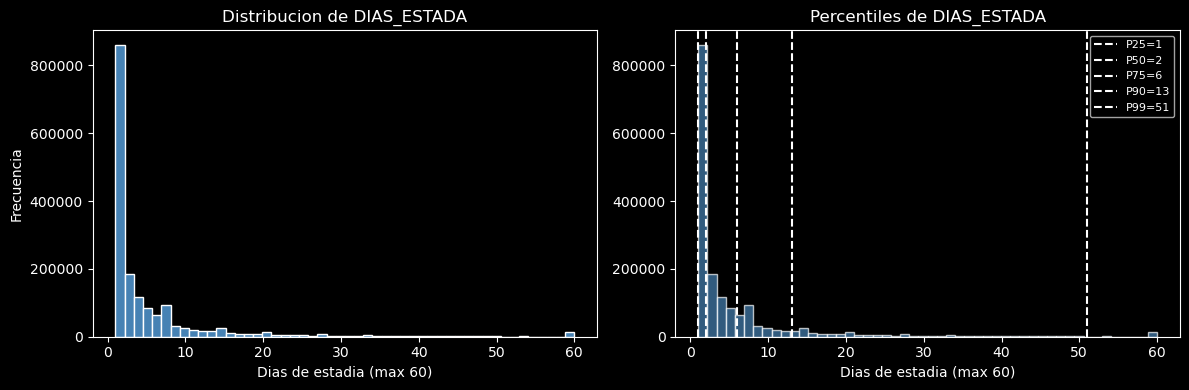

Estadisticas DIAS_ESTADA:
count    1667349.00
mean           6.09
std           40.36
min            1.00
25%            1.00
50%            2.00
75%            6.00
max        17858.00
Name: DIAS_ESTADA, dtype: float64


In [36]:
# histograma de DIAS_ESTADA
dias = df_raw['DIAS_ESTADA']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dias.clip(upper=60), bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Dias de estadia (max 60)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de DIAS_ESTADA')

axes[1].hist(dias.clip(upper=60), bins=50, color='steelblue', edgecolor='white', alpha=0.7)
for p, lbl in [(25,'P25'), (50,'P50'), (75,'P75'), (90,'P90'), (99,'P99')]:
    v = dias.quantile(p/100)
    axes[1].axvline(v, linestyle='--', label=f'{lbl}={v:.0f}')
axes[1].set_xlabel('Dias de estadia (max 60)')
axes[1].set_title('Percentiles de DIAS_ESTADA')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Estadisticas DIAS_ESTADA:')
print(dias.describe().round(2))


El dataset tiene 1.667.349 filas y 15 columnas. La variable DIAS_ESTADA tiene muchos valores chicos
(la mediana es 2 dias) pero hay algunos muy grandes. La distribucion es asimetrica hacia la derecha.

Las columnas de texto como SEXO y PREVISION tienen un valor '*' en algunos registros que hay que tratar.


## 2. Re-ajuste de tipos de variables

Hay columnas que quedaron como texto pero son categorias. Las voy a convertir a category.
DIAG2 tiene casi todo nulo asi que la elimino. ANO_EGRESO es siempre 2024 asi que tampoco sirve.


In [37]:
df = df_raw.copy()

# eliminar columnas que no sirven
print('DIAG2 nulos:', df['DIAG2'].isna().mean() * 100, '%')
df.drop(columns=['DIAG2'], inplace=True)

print('ANO_EGRESO valores:', df['ANO_EGRESO'].unique())
df.drop(columns=['ANO_EGRESO'], inplace=True)

# tipos numericos
df['DIAS_ESTADA'] = df['DIAS_ESTADA'].astype('int32')
df['CONDICION_EGRESO'] = df['CONDICION_EGRESO'].astype('int8')

# SEXO: mapear los codigos a etiquetas
sexo_map = {'1': 'Hombre', '2': 'Mujer', '*': 'No identificado'}
df['SEXO'] = df['SEXO'].map(sexo_map).astype('category')

# PREVISION
prev_map = {
    '1':'FONASA', '2':'ISAPRE', '3':'CAPREDENA', '4':'DIPRECA',
    '5':'SISA', '96':'Particular', '99':'Desconocida', '*':'No identificado'
}
df['PREVISION'] = df['PREVISION'].map(prev_map).fillna('Otra').astype('category')

# GRUPO_EDAD como categoria ordenada
orden_edad = [
    'menor a 7 días', '7 A 27 DIAS', '28 DIAS A 2 MES', '2 MESES A MENOS DE 1 AÑO',
    '1 A 4 AÑOS', '5 A 9 AÑOS', '10 A 14 AÑOS', '15 A 19 AÑOS',
    '20 A 24 AÑOS', '25 A 29 AÑOS', '30 A 34 AÑOS', '35 A 39 AÑOS',
    '40 A 44 AÑOS', '45 A 49 AÑOS', '50 A 54 AÑOS', '55 A 59 AÑOS',
    '60 A 64 AÑOS', '65 A 69 AÑOS', '70 A 74 AÑOS', '75 A 79 AÑOS',
    '80 A 84 AÑOS', '85 A MAS'
]
presentes = [g for g in orden_edad if g in df['GRUPO_EDAD'].unique()]
df['GRUPO_EDAD'] = pd.Categorical(df['GRUPO_EDAD'], categories=presentes, ordered=True)
df['edad_ordinal'] = df['GRUPO_EDAD'].cat.codes

# DIAG1
df['DIAG1'] = df['DIAG1'].str.strip().str.upper().astype('category')

# el resto de columnas object a category
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

# variable objetivo
df['estadia_prolongada'] = (df['DIAS_ESTADA'] >= 7).astype('int8')

print()
print('Tipos finales:')
print(df.dtypes)


DIAG2 nulos: 90.35972672787761 %
ANO_EGRESO valores: [2024]

Tipos finales:
PERTENENCIA_ESTABLECIMIENTO_SALUD    category
SEXO                                 category
GRUPO_EDAD                           category
GLOSA_PAIS_ORIGEN                    category
COMUNA_RESIDENCIA                    category
GLOSA_COMUNA_RESIDENCIA              category
REGION_RESIDENCIA                    category
GLOSA_REGION_RESIDENCIA              category
PREVISION                            category
GLOSA_PREVISION                      category
DIAG1                                category
DIAS_ESTADA                             int32
CONDICION_EGRESO                         int8
edad_ordinal                             int8
estadia_prolongada                       int8
dtype: object


In [38]:
# verificar que no quedan columnas object
no_cat = [c for c in df.columns if str(df[c].dtype) == 'object']
print('Columnas object restantes:', no_cat if no_cat else 'ninguna')
print()
print('SEXO categorias:', df['SEXO'].cat.categories.tolist())
print('PREVISION categorias:', df['PREVISION'].cat.categories.tolist())
print('GRUPO_EDAD ordenado:', df['GRUPO_EDAD'].cat.ordered)
print('Dataset:', df.shape[0], 'filas x', df.shape[1], 'columnas')


Columnas object restantes: ninguna

SEXO categorias: ['Hombre', 'Mujer', 'No identificado']
PREVISION categorias: ['CAPREDENA', 'DIPRECA', 'Desconocida', 'FONASA', 'ISAPRE', 'No identificado', 'Particular', 'SISA']
GRUPO_EDAD ordenado: True
Dataset: 1667349 filas x 15 columnas


Todas las columnas de texto pasaron a category. El '*' en SEXO y PREVISION lo mapeé a 'No identificado'
para no perder esos registros. GRUPO_EDAD quedo ordenado. DIAG2 y ANO_EGRESO los elimine porque no
aportan informacion util.


## 3. Datos ausentes

Despues de convertir los tipos veo cuantos nulos quedan y que hacer con ellos.


Columnas con nulos:
                   nulos   pct
REGION_RESIDENCIA    912  0.05


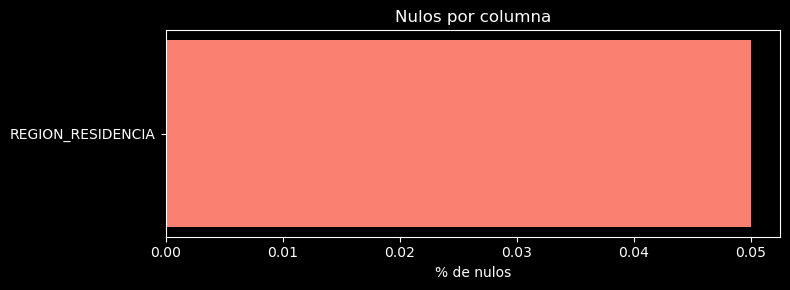

In [39]:
# ver nulos por columna
nulos = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'pct': (df.isnull().sum() / len(df) * 100).round(2)
})
con_nulos = nulos[nulos['nulos'] > 0].sort_values('nulos', ascending=False)
print('Columnas con nulos:')
print(con_nulos if not con_nulos.empty else 'No hay nulos')

if not con_nulos.empty:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.barh(con_nulos.index, con_nulos['pct'], color='salmon')
    ax.set_xlabel('% de nulos')
    ax.set_title('Nulos por columna')
    plt.tight_layout()
    plt.show()


In [40]:
# ver si los 'No identificado' de SEXO y PREVISION son los mismos registros
mask_sexo = df['SEXO'] == 'No identificado'
mask_prev = df['PREVISION'] == 'No identificado'

print('SEXO No identificado:', mask_sexo.sum())
print('PREVISION No identificado:', mask_prev.sum())
print('Ambos:', (mask_sexo & mask_prev).sum())
print()
print('Son el mismo bloque de registros. Se conservan como categoria valida.')


SEXO No identificado: 28382
PREVISION No identificado: 28382
Ambos: 28382

Son el mismo bloque de registros. Se conservan como categoria valida.


In [41]:
# regiones especiales
for reg in ['Ignorada', 'Extranjero']:
    n = (df['GLOSA_REGION_RESIDENCIA'] == reg).sum()
    print(f'Region "{reg}": {n} registros')

print()
print('Se mantienen en el analisis general pero se excluyen en comparaciones regionales.')


Region "Ignorada": 18673 registros
Region "Extranjero": 912 registros

Se mantienen en el analisis general pero se excluyen en comparaciones regionales.


In [42]:
# resumen de lo que se hizo con los datos ausentes
print('RESUMEN:')
print('DIAG2: eliminada (90% nulos)')
print('ANO_EGRESO: eliminada (constante)')
print('SEXO/PREVISION con *: conservados como No identificado')
print('Region Ignorada/Extranjero: conservados')
print()
for c in ['DIAS_ESTADA','CONDICION_EGRESO','DIAG1','SEXO','PREVISION','GRUPO_EDAD']:
    print(f'  {c}: nulos = {df[c].isnull().sum()}')


RESUMEN:
DIAG2: eliminada (90% nulos)
ANO_EGRESO: eliminada (constante)
SEXO/PREVISION con *: conservados como No identificado
Region Ignorada/Extranjero: conservados

  DIAS_ESTADA: nulos = 0
  CONDICION_EGRESO: nulos = 0
  DIAG1: nulos = 0
  SEXO: nulos = 0
  PREVISION: nulos = 0
  GRUPO_EDAD: nulos = 0


Las variables principales (DIAS_ESTADA, DIAG1, SEXO, GRUPO_EDAD) no tienen nulos.
Los 28.382 registros con 'No identificado' son el mismo bloque en SEXO y PREVISION,
los dejo como categoria valida. No elimine ni impute ningun registro.


## 4. Outliers en DIAS_ESTADA

Hay estadias muy largas. Voy a ver si son errores o casos reales.


In [43]:
print('Estadisticas DIAS_ESTADA:')
print(df['DIAS_ESTADA'].describe().round(2))


Estadisticas DIAS_ESTADA:
count    1667349.00
mean           6.09
std           40.36
min            1.00
25%            1.00
50%            2.00
75%            6.00
max        17858.00
Name: DIAS_ESTADA, dtype: float64


In [44]:
# criterio IQR para detectar outliers
Q1 = df['DIAS_ESTADA'].quantile(0.25)
Q3 = df['DIAS_ESTADA'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR
p99 = df['DIAS_ESTADA'].quantile(0.99)

n_outliers = (df['DIAS_ESTADA'] > limite_sup).sum()
n_p99 = (df['DIAS_ESTADA'] > p99).sum()

print(f'Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}')
print(f'Limite superior: {limite_sup:.0f} dias')
print(f'Outliers IQR: {n_outliers} ({n_outliers/len(df)*100:.2f}%)')
print(f'Outliers P99 (>{p99:.0f} dias): {n_p99} ({n_p99/len(df)*100:.2f}%)')


Q1=1  Q3=6  IQR=5
Limite superior: 14 dias
Outliers IQR: 152329 (9.14%)
Outliers P99 (>51 dias): 16517 (0.99%)


In [45]:
# como afectan los outliers a la media
media_full = df['DIAS_ESTADA'].mean()
media_sin = df.loc[df['DIAS_ESTADA'] <= p99, 'DIAS_ESTADA'].mean()
mediana = df['DIAS_ESTADA'].median()

print(f'Media con outliers:  {media_full:.2f} dias')
print(f'Media sin outliers:  {media_sin:.2f} dias')
print(f'Mediana:             {mediana:.0f} dias')


Media con outliers:  6.09 dias
Media sin outliers:  4.87 dias
Mediana:             2 dias


In [46]:
# los 15 casos con estadia mas larga
cols = ['DIAS_ESTADA','GRUPO_EDAD','SEXO','DIAG1','GLOSA_REGION_RESIDENCIA','CONDICION_EGRESO']
print('Top 15 estadias mas largas:')
print(df[cols].nlargest(15, 'DIAS_ESTADA').to_string(index=False))


Top 15 estadias mas largas:
 DIAS_ESTADA               GRUPO_EDAD   SEXO DIAG1   GLOSA_REGION_RESIDENCIA  CONDICION_EGRESO
       17858             45 A 49 AÑOS  Mujer  R092 Metropolitana de Santiago                 2
       15162             20 A 24 AÑOS  Mujer  F720             De Valparaíso                 1
       13514             45 A 49 AÑOS  Mujer  J960 Metropolitana de Santiago                 2
       11493             50 A 54 AÑOS  Mujer  R092 Metropolitana de Santiago                 2
       11180             45 A 49 AÑOS  Mujer  R092 Metropolitana de Santiago                 2
       11147             30 A 34 AÑOS  Mujer  J960 Metropolitana de Santiago                 2
        9950             30 A 34 AÑOS Hombre  F729             De Valparaíso                 1
        9105             30 A 34 AÑOS Hombre  F203 Metropolitana de Santiago                 1
        8683             45 A 49 AÑOS  Mujer  J960 Metropolitana de Santiago                 2
        7750          

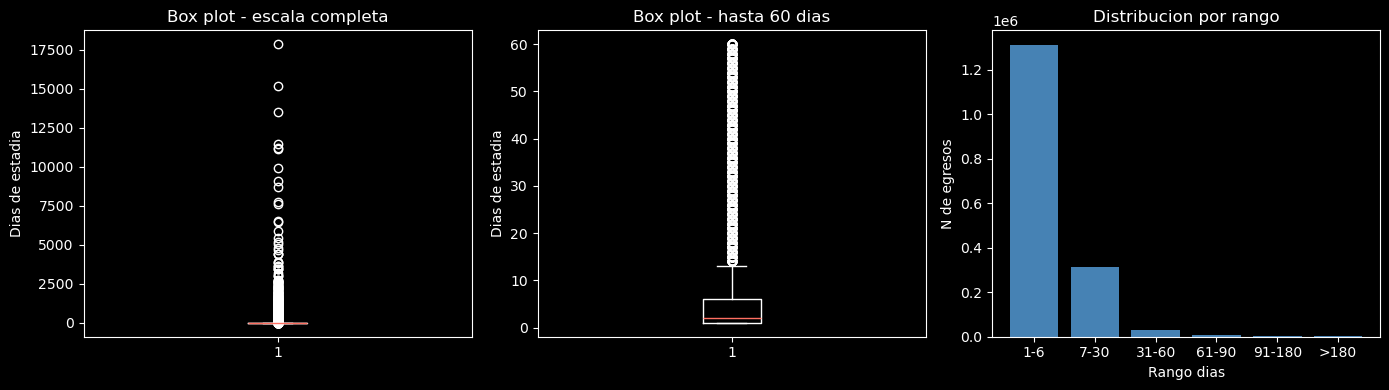

In [47]:
# graficos de outliers
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# boxplot completo
axes[0].boxplot(df['DIAS_ESTADA'].values)
axes[0].set_title('Box plot - escala completa')
axes[0].set_ylabel('Dias de estadia')

# boxplot acotado a 60
axes[1].boxplot(df['DIAS_ESTADA'].clip(upper=60).values)
axes[1].set_title('Box plot - hasta 60 dias')
axes[1].set_ylabel('Dias de estadia')

# barras por rango
rangos = [0, 6, 30, 60, 90, 180, 99999]
etiquetas = ['1-6', '7-30', '31-60', '61-90', '91-180', '>180']
dias_np = df['DIAS_ESTADA'].values
conteos = [int(((dias_np > rangos[i]) & (dias_np <= rangos[i+1])).sum()) for i in range(len(etiquetas))]
axes[2].bar(etiquetas, conteos, color='steelblue')
axes[2].set_xlabel('Rango dias')
axes[2].set_ylabel('N de egresos')
axes[2].set_title('Distribucion por rango')

plt.tight_layout()
plt.show()


In [48]:
# agrego una columna flag para identificar outliers extremos
df['outlier_extremo'] = (df['DIAS_ESTADA'] > 180).astype('int8')

print('Outliers extremos (>180 dias):', df['outlier_extremo'].sum(), f'({df["outlier_extremo"].mean()*100:.2f}%)')
print()
print('Decidi no eliminarlos porque los casos de estadias muy largas parecen')
print('ser hospitalizaciones por salud mental, demencias, etc. Son casos reales.')
print('Agrego el flag "outlier_extremo" por si se necesita filtrar despues.')


Outliers extremos (>180 dias): 1601 (0.10%)

Decidi no eliminarlos porque los casos de estadias muy largas parecen
ser hospitalizaciones por salud mental, demencias, etc. Son casos reales.
Agrego el flag "outlier_extremo" por si se necesita filtrar despues.


Segun el criterio IQR el 14% de los registros son outliers, pero eso es normal en datos hospitalarios
porque la distribucion es muy asimetrica. Los casos con estadia >180 dias corresponden principalmente
a diagnosticos de salud mental y adultos mayores, por lo que son clinicamente validos.

Decidi no eliminarlos. Agrego un flag y uso 'estadia_prolongada' (>=7 dias) como variable objetivo.


## 5. Relaciones entre variables

Veo como se relacionan las variables con la estadia prolongada.


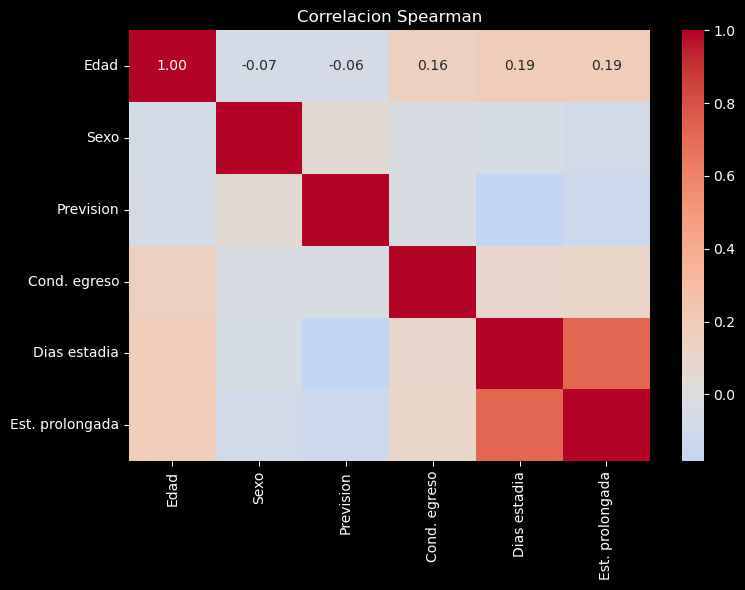

Correlacion con estadia_prolongada:
Dias estadia    0.7264
Edad            0.1871
Cond. egreso    0.1051
Sexo           -0.0908
Prevision      -0.1242
Name: Est. prolongada, dtype: float64


In [49]:
# correlacion de Spearman entre variables numericas
df['sexo_num'] = df['SEXO'].cat.codes
df['prev_num'] = df['PREVISION'].cat.codes
df['cond_num'] = df['CONDICION_EGRESO'].astype(float)

vars_num = ['edad_ordinal','sexo_num','prev_num','cond_num','DIAS_ESTADA','estadia_prolongada']
nombres = ['Edad','Sexo','Prevision','Cond. egreso','Dias estadia','Est. prolongada']

corr_sp = df[vars_num].corr(method='spearman')
corr_sp.columns = nombres
corr_sp.index = nombres

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_sp, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlacion Spearman')
plt.tight_layout()
plt.show()

print('Correlacion con estadia_prolongada:')
print(corr_sp['Est. prolongada'].drop('Est. prolongada').sort_values(ascending=False).round(4))


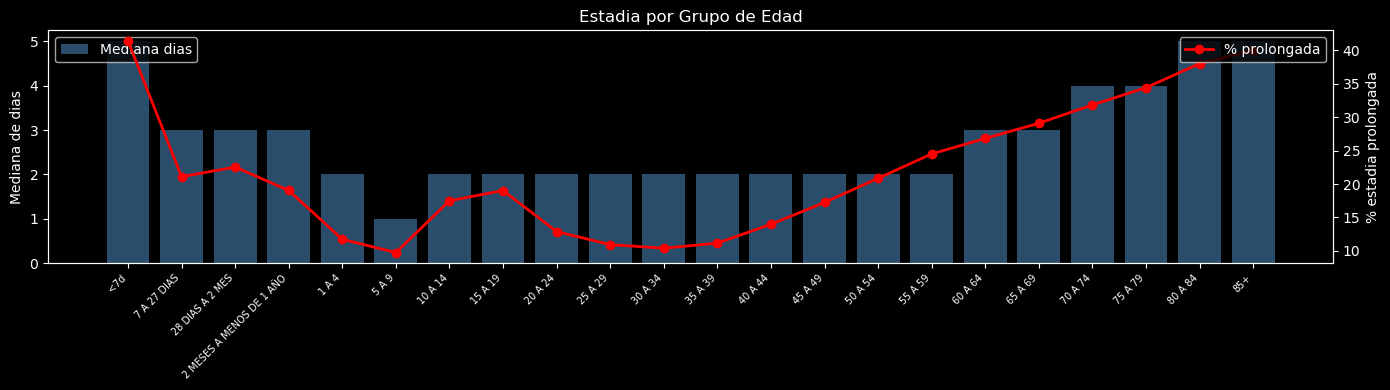

              GRUPO_EDAD  mediana  pct_prol      n
          menor a 7 días      5.0 41.433067  27326
             7 A 27 DIAS      3.0 21.094490   5281
         28 DIAS A 2 MES      3.0 22.540161   3984
2 MESES A MENOS DE 1 AÑO      3.0 19.038807  18914
              1 A 4 AÑOS      2.0 11.724164  53829
              5 A 9 AÑOS      1.0  9.737963  52588
            10 A 14 AÑOS      2.0 17.498083  46948
            15 A 19 AÑOS      2.0 19.023699  54348
            20 A 24 AÑOS      2.0 12.883993  80340
            25 A 29 AÑOS      2.0 10.927839 110946
            30 A 34 AÑOS      2.0 10.391812 137464
            35 A 39 AÑOS      2.0 11.150090 125138
            40 A 44 AÑOS      2.0 13.975807  99615
            45 A 49 AÑOS      2.0 17.244060  87462
            50 A 54 AÑOS      2.0 20.862258  91040
            55 A 59 AÑOS      2.0 24.510159 102125
            60 A 64 AÑOS      3.0 26.831561 115953
            65 A 69 AÑOS      3.0 29.100411 116720
            70 A 74 AÑOS      4

In [50]:
# estadia por grupo de edad
edad_stats = (
    df.groupby('GRUPO_EDAD', observed=True)
    .agg(pct_prol=('estadia_prolongada','mean'), mediana=('DIAS_ESTADA','median'), n=('DIAS_ESTADA','count'))
    .reset_index()
)
edad_stats['pct_prol'] = edad_stats['pct_prol'] * 100

etiq = [str(g).replace(' AÑOS','').replace('menor a 7 días','<7d').replace('85 A MAS','85+') for g in edad_stats['GRUPO_EDAD']]

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
x = range(len(edad_stats))
ax1.bar(x, edad_stats['mediana'], color='steelblue', alpha=0.6, label='Mediana dias')
ax2.plot(x, edad_stats['pct_prol'], color='red', marker='o', lw=2, label='% prolongada')
ax1.set_xticks(list(x))
ax1.set_xticklabels(etiq, rotation=45, ha='right', fontsize=7)
ax1.set_ylabel('Mediana de dias')
ax2.set_ylabel('% estadia prolongada')
ax1.set_title('Estadia por Grupo de Edad')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(edad_stats[['GRUPO_EDAD','mediana','pct_prol','n']].to_string(index=False))


              SEXO  pct_prol  mediana       n
0           Hombre     25.64      3.0  704881
1            Mujer     18.29      2.0  934086
2  No identificado     14.42      2.0   28382

Mann-Whitney p=0.0000
-> Diferencia significativa entre hombres y mujeres


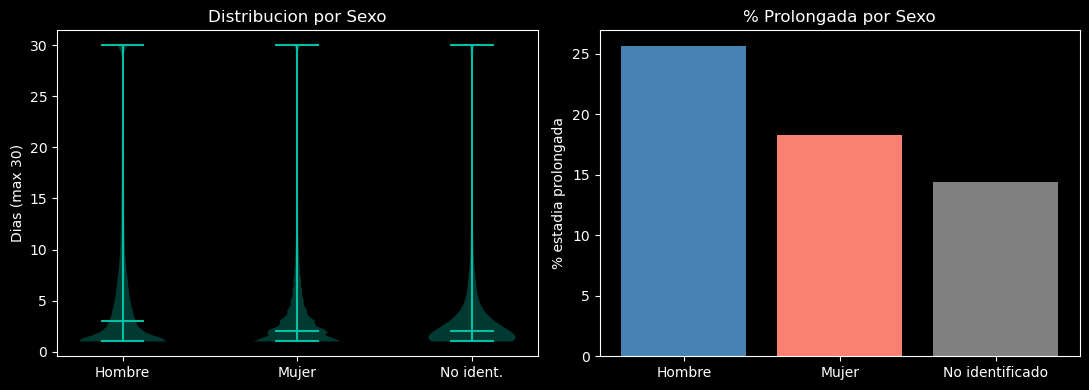

In [51]:
# estadia por sexo
sexo_stats = (
    df.groupby('SEXO', observed=True)
    .agg(pct_prol=('estadia_prolongada','mean'), mediana=('DIAS_ESTADA','median'), n=('DIAS_ESTADA','count'))
    .reset_index()
)
sexo_stats['pct_prol'] = sexo_stats['pct_prol'] * 100
print(sexo_stats.round(2))

# test estadistico
h = df[df['SEXO']=='Hombre']['DIAS_ESTADA']
m = df[df['SEXO']=='Mujer']['DIAS_ESTADA']
u, p = stats.mannwhitneyu(h, m, alternative='two-sided')
print(f'\nMann-Whitney p={p:.4f}')
if p < 0.05:
    print('-> Diferencia significativa entre hombres y mujeres')
else:
    print('-> No hay diferencia significativa')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# violin
grupos = [df[df['SEXO']==s]['DIAS_ESTADA'].clip(upper=30).values for s in ['Hombre','Mujer','No identificado']]
axes[0].violinplot(grupos, positions=[1,2,3], showmedians=True)
axes[0].set_xticks([1,2,3])
axes[0].set_xticklabels(['Hombre','Mujer','No ident.'])
axes[0].set_ylabel('Dias (max 30)')
axes[0].set_title('Distribucion por Sexo')

# barras
axes[1].bar(sexo_stats['SEXO'].astype(str), sexo_stats['pct_prol'], color=['steelblue','salmon','gray'])
axes[1].set_ylabel('% estadia prolongada')
axes[1].set_title('% Prolongada por Sexo')

plt.tight_layout()
plt.show()


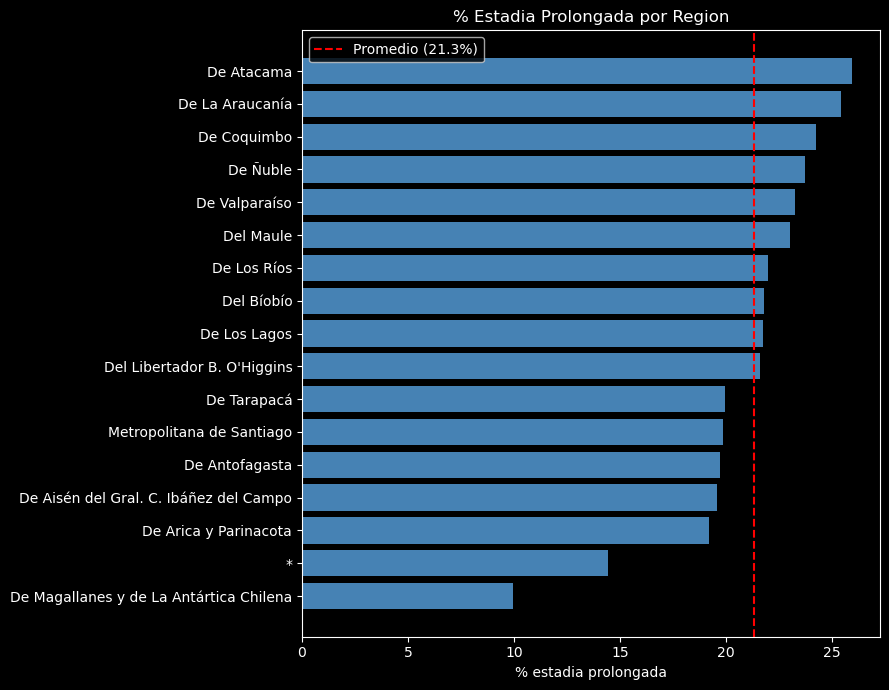

In [52]:
# estadia por region
media_global = df['estadia_prolongada'].mean() * 100

reg_stats = (
    df[~df['GLOSA_REGION_RESIDENCIA'].isin(['Ignorada','Extranjero'])]
    .groupby('GLOSA_REGION_RESIDENCIA', observed=True)
    .agg(pct_prol=('estadia_prolongada','mean'), n=('estadia_prolongada','count'))
    .reset_index()
)
reg_stats['pct_prol'] = reg_stats['pct_prol'] * 100
reg_stats = reg_stats.sort_values('pct_prol')

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(reg_stats['GLOSA_REGION_RESIDENCIA'].astype(str), reg_stats['pct_prol'], color='steelblue')
ax.axvline(media_global, color='red', lw=1.5, ls='--', label=f'Promedio ({media_global:.1f}%)')
ax.set_xlabel('% estadia prolongada')
ax.set_title('% Estadia Prolongada por Region')
ax.legend()
plt.tight_layout()
plt.show()


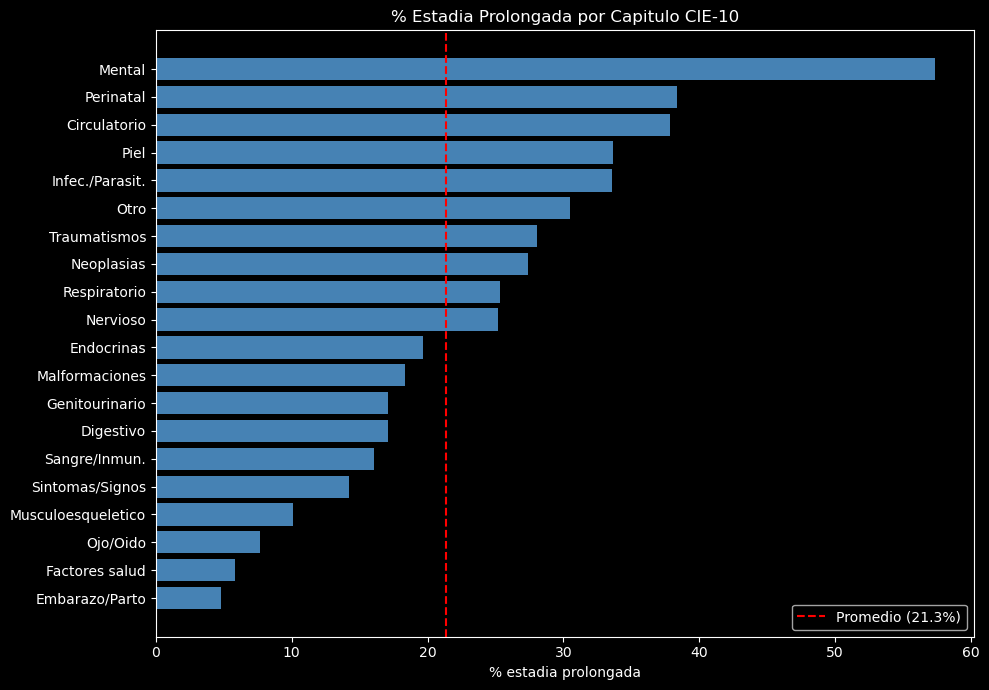

Top 5 capitulos con mas estadias prolongadas:
 capitulo_cie10      n  pct_prol  mediana
         Mental  43005 57.335194      8.0
      Perinatal  29047 38.355080      4.0
   Circulatorio 151768 37.836698      5.0
           Piel  23566 33.641687      4.0
Infec./Parasit.  36352 33.544234      4.0


In [53]:
# estadia por capitulo CIE-10
cap_map = {
    'A':'Infec./Parasit.','B':'Infec./Parasit.','C':'Neoplasias','D':'Sangre/Inmun.',
    'E':'Endocrinas','F':'Mental','G':'Nervioso','H':'Ojo/Oido',
    'I':'Circulatorio','J':'Respiratorio','K':'Digestivo','L':'Piel',
    'M':'Musculoesqueletico','N':'Genitourinario','O':'Embarazo/Parto',
    'P':'Perinatal','Q':'Malformaciones','R':'Sintomas/Signos',
    'S':'Traumatismos','T':'Traumatismos','V':'Causas externas',
    'W':'Causas externas','X':'Causas externas','Y':'Causas externas','Z':'Factores salud'
}
df['capitulo_cie10'] = df['DIAG1'].astype(str).str[0].map(cap_map).fillna('Otro').astype('category')

cap_stats = (
    df.groupby('capitulo_cie10', observed=True)
    .agg(pct_prol=('estadia_prolongada','mean'), mediana=('DIAS_ESTADA','median'), n=('DIAS_ESTADA','count'))
    .reset_index()
)
cap_stats['pct_prol'] = cap_stats['pct_prol'] * 100
cap_stats = cap_stats[cap_stats['n'] >= 1000].sort_values('pct_prol')

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(cap_stats['capitulo_cie10'].astype(str), cap_stats['pct_prol'], color='steelblue')
ax.axvline(media_global, color='red', lw=1.5, ls='--', label=f'Promedio ({media_global:.1f}%)')
ax.set_xlabel('% estadia prolongada')
ax.set_title('% Estadia Prolongada por Capitulo CIE-10')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 5 capitulos con mas estadias prolongadas:')
print(cap_stats.sort_values('pct_prol', ascending=False).head(5)[['capitulo_cie10','n','pct_prol','mediana']].to_string(index=False))


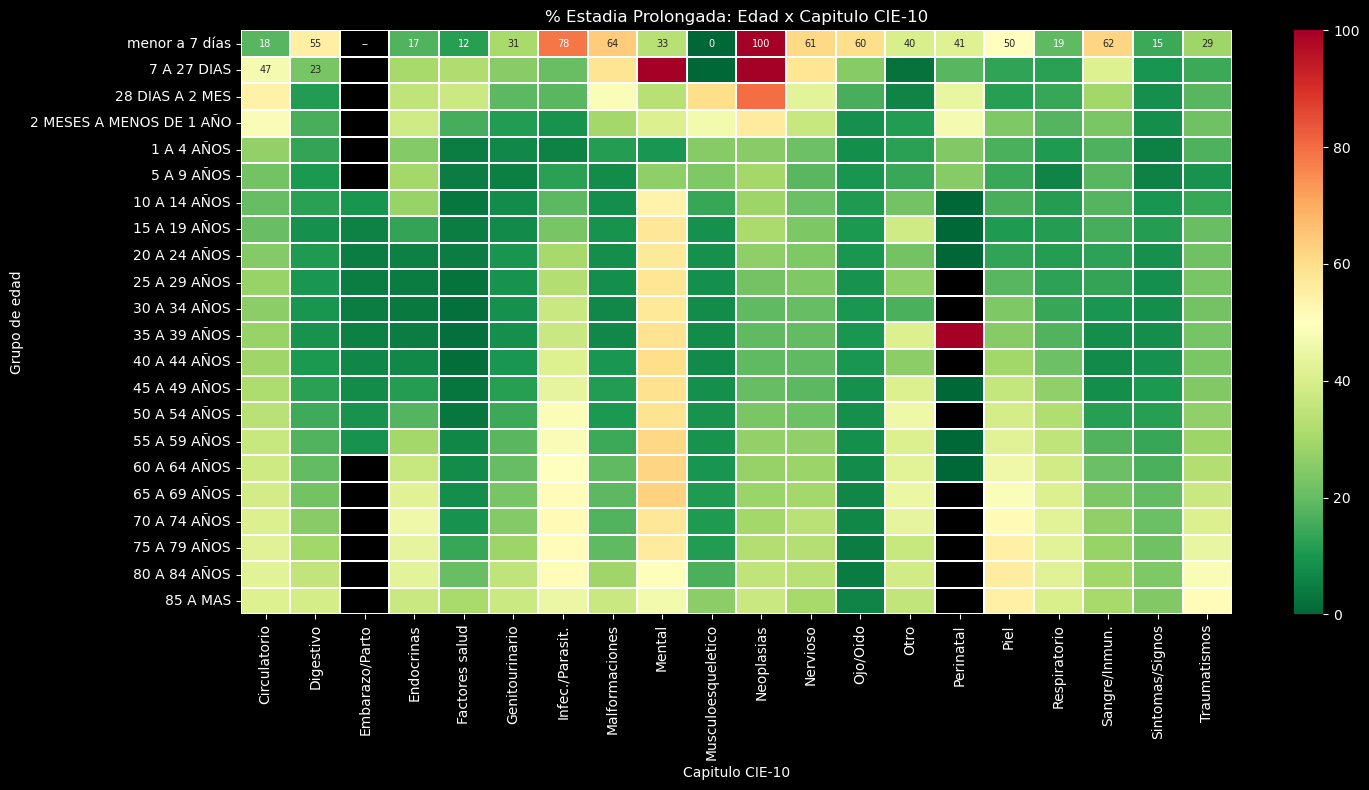

In [54]:
# heatmap: edad x capitulo CIE-10
pivot = (
    df.groupby(['GRUPO_EDAD','capitulo_cie10'], observed=True)['estadia_prolongada']
    .mean().unstack() * 100
)
pivot = pivot.dropna(thresh=8, axis=1)

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.0f', linewidths=0.3,
            annot_kws={'size': 7})
ax.set_title('% Estadia Prolongada: Edad x Capitulo CIE-10')
ax.set_xlabel('Capitulo CIE-10')
ax.set_ylabel('Grupo de edad')
plt.tight_layout()
plt.show()


      PREVISION  pct_prol  mediana       n
      CAPREDENA     25.27      2.0   16246
         FONASA     24.51      3.0 1250994
           SISA     23.59      2.0   11064
        DIPRECA     20.76      2.0   22654
    Desconocida     17.05      2.0   19418
     Particular     15.56      2.0   17505
No identificado     14.42      2.0   28382
         ISAPRE      9.14      1.0  301086


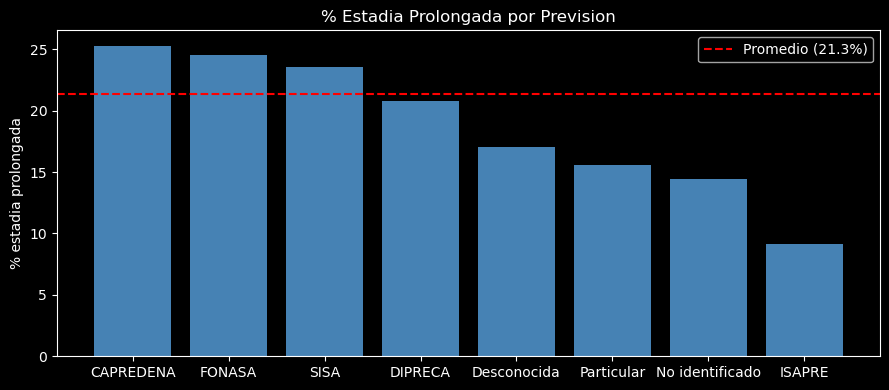

In [55]:
# estadia por prevision
prev_stats = (
    df.groupby('PREVISION', observed=True)
    .agg(pct_prol=('estadia_prolongada','mean'), mediana=('DIAS_ESTADA','median'), n=('DIAS_ESTADA','count'))
    .reset_index()
)
prev_stats['pct_prol'] = prev_stats['pct_prol'] * 100
prev_stats = prev_stats[prev_stats['n'] >= 100].sort_values('pct_prol', ascending=False)
print(prev_stats.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(prev_stats['PREVISION'].astype(str), prev_stats['pct_prol'], color='steelblue')
ax.axhline(media_global, color='red', lw=1.5, ls='--', label=f'Promedio ({media_global:.1f}%)')
ax.set_ylabel('% estadia prolongada')
ax.set_title('% Estadia Prolongada por Prevision')
ax.legend()
plt.tight_layout()
plt.show()


In [56]:
# resumen comparativo
rango_edad = edad_stats['pct_prol'].max() - edad_stats['pct_prol'].min()
rango_reg  = reg_stats['pct_prol'].max()  - reg_stats['pct_prol'].min()
rango_cap  = cap_stats['pct_prol'].max()  - cap_stats['pct_prol'].min()
rango_prev = prev_stats['pct_prol'].max() - prev_stats['pct_prol'].min()

print('Variacion en % estadia prolongada por variable:')
print(f'  Grupo de edad:   {rango_edad:.1f} pp')
print(f'  Region:          {rango_reg:.1f} pp')
print(f'  Capitulo CIE-10: {rango_cap:.1f} pp')
print(f'  Prevision:       {rango_prev:.1f} pp')
print()
print('Correlacion Spearman con estadia_prolongada:')
print(corr_sp['Est. prolongada'].drop('Est. prolongada').sort_values(ascending=False).round(4))


Variacion en % estadia prolongada por variable:
  Grupo de edad:   31.7 pp
  Region:          16.0 pp
  Capitulo CIE-10: 52.6 pp
  Prevision:       16.1 pp

Correlacion Spearman con estadia_prolongada:
Dias estadia    0.7264
Edad            0.1871
Cond. egreso    0.1051
Sexo           -0.0908
Prevision      -0.1242
Name: Est. prolongada, dtype: float64


La mayor correlacion Spearman con estadia_prolongada la tiene la edad ordinal, seguida de la condicion de egreso.

El capitulo CIE-10 es la variable con mayor rango de variacion entre grupos (mas de 40 puntos porcentuales).
El heatmap muestra que los adultos mayores con diagnosticos mentales o neurologicos tienen el mayor riesgo
de tener una estadia prolongada.

En conclusion, el diagnostico y la edad son los predictores mas importantes individualmente, pero
interactuan entre si segun el heatmap.
